## Импорт библиотек

In [1]:
import os
import random
import time
import warnings
import datetime as dt

import numpy as np
import pandas as pd
import requests
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Literal
from random import randint

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV,
)

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import uniform, randint, loguniform

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_rows', 1001)
pd.set_option('display.max_columns', 60)

sns.set(style="whitegrid")

## Соединение 2х data-frame-ов (выработки и исторических данных о погоде):

Подгрузка данных о погоде

In [3]:
historical_weather = pd.read_csv('historical_weather.csv', index_col=0) 

Подгрузка данных о выработке

In [4]:
production = pd.read_excel('production.xlsx')

In [5]:
historical_weather['date'] = pd.to_datetime(historical_weather['date'])

historical_weather = historical_weather[
    (historical_weather['date'].dt.hour >= 8) & 
    (historical_weather['date'].dt.hour < 20)
]

Приведение данных об исторической энерговыработке к числовому формату 

In [6]:
production['production'] = pd.to_numeric(production['production'], errors='coerce')

Объединение исторических данных о погоде и выработаботке

In [7]:
historical_weather["date"] = pd.to_datetime(historical_weather['date']).dt.date 
production["date"] = pd.to_datetime(production["date"]).dt.date

meteo_and_prod = pd.merge(
    historical_weather,
    production,
    on='date',
    how='left',
)

meteo_and_prod.head()

sum_columns = ['global_tilted_irradiance', 'direct_normal_irradiance', 'direct_radiation', 'diffuse_radiation', 'terrestrial_radiation', 'shortwave_radiation']
mean_columns = ['cloud_cover', 'relative_humidity_2m', 'temperature_2m', 
                        'wind_speed_10m', 'surface_pressure']

for col in meteo_and_prod.columns:
    if col not in ['id_station', 'date', 'production']:
        if col in mean_columns and pd.api.types.is_numeric_dtype(meteo_and_prod[col]):
            mean_columns.append(col) if col not in mean_columns else None
        elif pd.api.types.is_numeric_dtype(meteo_and_prod[col]):
            sum_columns.append(col)
    
agg_dict = {}
for col in sum_columns:
    agg_dict[col] = 'sum'
for col in mean_columns:
    if col in meteo_and_prod.columns and pd.api.types.is_numeric_dtype(meteo_and_prod[col]):
        agg_dict[col] = 'mean'
    
if 'production' in meteo_and_prod.columns:
    agg_dict['production'] = 'first'
    
meteo_and_prod = (
    meteo_and_prod.groupby(['id_station', 'date'])
    .agg(agg_dict)
    .reset_index()
)

meteo_and_prod['production'] = meteo_and_prod['production'].round(2)

meteo_and_prod.head()


,id_station,date,global_tilted_irradiance,direct_normal_irradiance,direct_radiation,diffuse_radiation,terrestrial_radiation,shortwave_radiation,cloud_cover,relative_humidity_2m,temperature_2m,wind_speed_10m,surface_pressure,production
0,1,2024-01-31,955,970.700,230,725,1966.500,955,68.333,87.750,-6.050,13.508,990.342,27551.200
1,1,2024-02-01,743,196.900,55,688,2004.300,743,100.000,92.167,-9.958,15.217,983.108,27869.180
2,1,2024-02-02,307,0.000,0,307,2042.300,307,100.000,94.500,-3.983,15.008,971.100,29016.500
3,1,2024-02-03,704,412.500,95,609,2081.200,704,96.167,84.750,-5.417,20.425,968.492,18959.070
4,1,2024-02-04,450,0.000,0,450,2123.600,450,100.000,91.750,-4.467,18.908,963.708,10237.500


Сортировка по дате данных

In [8]:
meteo_and_prod.sort_values(by='date', inplace=True)

Вычисление межквартального размаха на тестовых данных и удаление выбросов 

In [9]:
test_data = meteo_and_prod.iloc[0:int(len(meteo_and_prod) * 0.8)]

test_data.drop(columns=['date'], inplace=True)

q1 = test_data['production'].quantile(0.25)
q3 = test_data['production'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr 
upper_bound = q3 + 1.5 * iqr

meteo_and_prod.loc[(meteo_and_prod['production'] < lower_bound) | (meteo_and_prod['production'] > upper_bound), 'production'] = np.nan

Удаление пропусков

In [10]:
meteo_and_prod.dropna(subset='production', inplace=True)

Удаление дубликатов


In [11]:
meteo_and_prod.drop_duplicates(subset=['date', 'id_station'], keep='first', inplace=True)

## Построение корреляционной матрицы

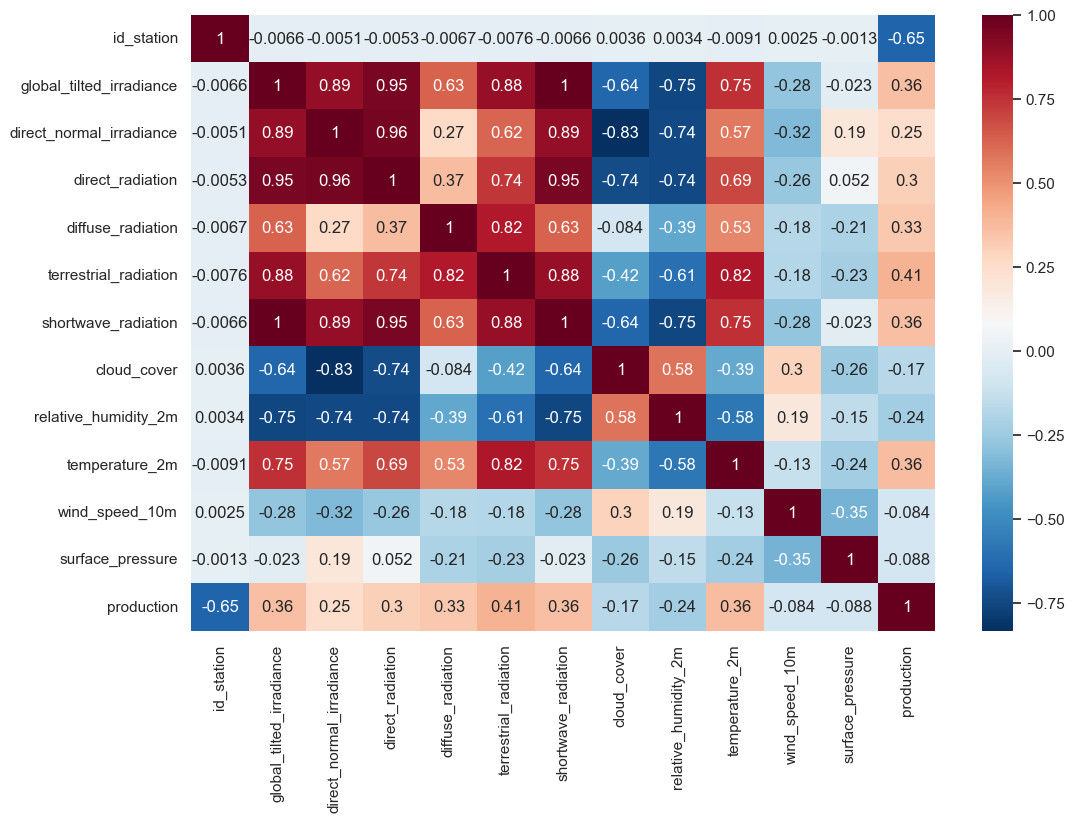

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(test_data.corr(), annot=True, cmap='RdBu_r')
plt.show()

# Подготовка к обучению моделей

Инициализация функции для расчета WAPE

In [13]:
def wape(y_pred, y_true):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

Инициализация функции для построения диаграм рассеивания


In [23]:
def plot_predictions_vs_true(y_pred: pd.Series, y: pd.Series):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_pred, y=y, alpha=0.3)

    max_val = max(y.max(), y_pred.max())

    plt.plot([0, max_val], [0, max_val], c='r', linestyle='--')
    
    plt.title(f"MAE: {mean_absolute_error(y_pred, y):.2f}, R2: {r2_score(y_pred, y):.2f}, WAPE: {wape(y_pred, y):.2f}")
    plt.xlabel("Предсказание")
    plt.ylabel("Выработка")
    plt.legend()
    plt.show()


Создание новых Dataframe-ов (с обработанными данными и с необработанными данными)

In [24]:
processed_meteo_and_prod = meteo_and_prod.copy()

processed_meteo_and_prod = processed_meteo_and_prod.drop(columns=["surface_pressure", "wind_speed_10m"])
processed_meteo_and_prod = processed_meteo_and_prod.drop(columns=['global_tilted_irradiance', 'direct_normal_irradiance', 'direct_radiation', 'shortwave_radiation'])

Деление обработанных (без избыточных и мультиколлинеарных признаков) и необработанных данных на обучающие (DataFrame с метеопризнаками) и тестовые (Series с целевой переменной-production)

In [25]:
x_train_p, x_test_p, y_train_p, y_test_p = train_test_split(processed_meteo_and_prod.drop(columns=['production', 'date']),
                                                    processed_meteo_and_prod['production'], 
                                                    test_size=0.2) # ..._p - processed (обработанные)

x_train, x_test, y_train, y_test = train_test_split(meteo_and_prod.drop(columns=['production', 'date']),
                                                    meteo_and_prod['production'], 
                                                    test_size=0.2)


Создание экземпляра TimeSeriesSplit для специальной настройки моделей, которая не дает им заглядывать в будующее (специальный инструмент для кросс-валидации временных рядов, где критически важен порядок данных)

In [26]:
tscv = TimeSeriesSplit(n_splits=10) # n_splits - количество разбиений данных при кросс-валидации

Установка random_state

In [27]:
RANDOM_STATE = 42 # так называемый "ключ" для фиксации результатов

Установка количества итераций поиска для RandomizedSearchCV и HalvingRandomSearchCV

In [28]:
N_ITER_SEARCH = 60 

# Обучение моделей

## Дерево решений

Создание сетки параметров для подбора 

In [29]:
param_grid_for_trees = { 
    'max_depth': [5, 10, 15, None], 
    'min_samples_split': [2, 5, 10], 
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.001, 0.01],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']
}

### GridSearchCV

#### На необработанных данных

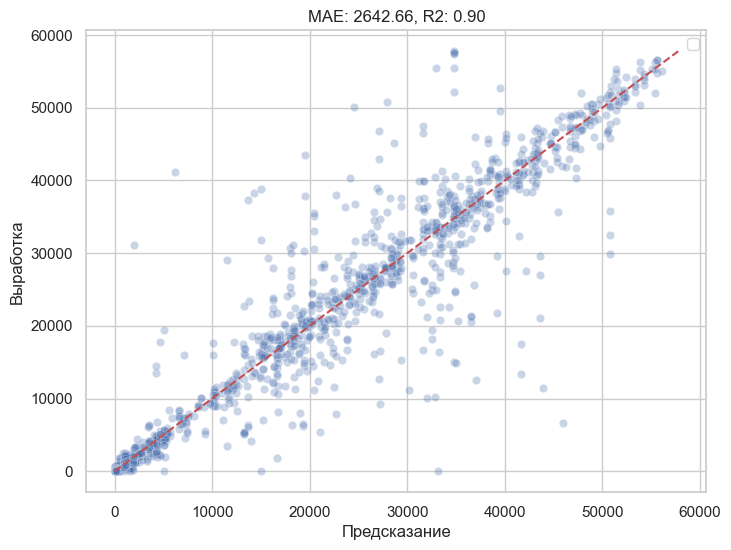

In [ ]:
decisionTree_GSCV = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_for_trees, 
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    refit='average_error', 
    n_jobs=-1 
)

decisionTree_GSCV.fit(x_train, y_train)
plot_predictions_vs_true(decisionTree_GSCV.predict(x_test), y_test)


#### На обработанных данных

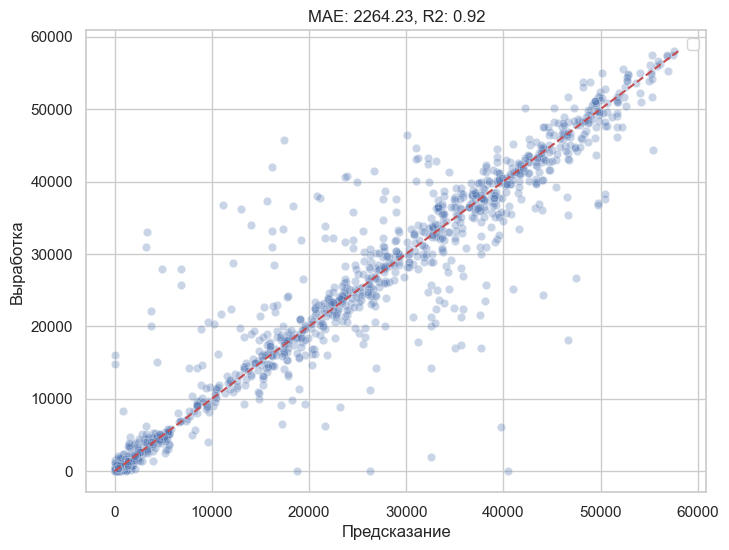

In [ ]:
decisionTree_GSCV = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_for_trees, 
    cv=tscv,
    scoring={
        'accuracy_r2': 'r2',
        'average_error': 'neg_mean_absolute_error'
    },
    refit='average_error', 
    n_jobs=-1 
)

decisionTree_GSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(decisionTree_GSCV.predict(x_test_p), y_test_p)


### RandomizedSearchCV

#### На необработанных данных

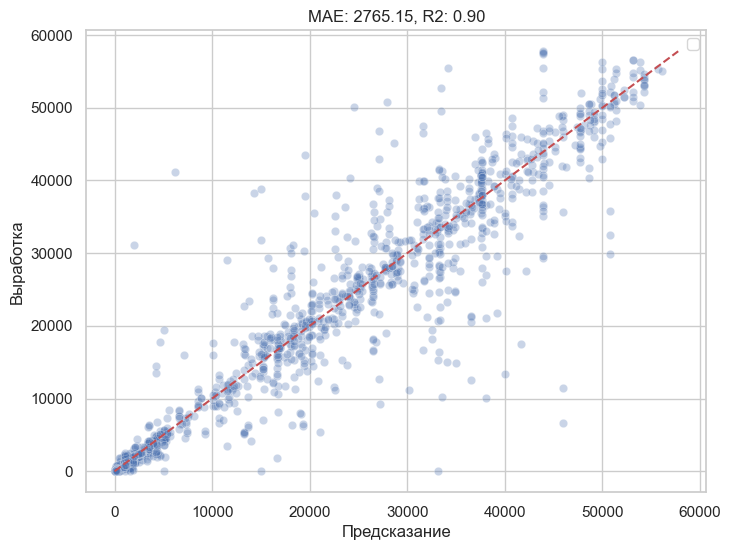

In [ ]:
decisionTree_RSCV = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees, 
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

decisionTree_RSCV.fit(x_train, y_train)

plot_predictions_vs_true(decisionTree_RSCV.predict(x_test), y_test)


#### На обработанных данных

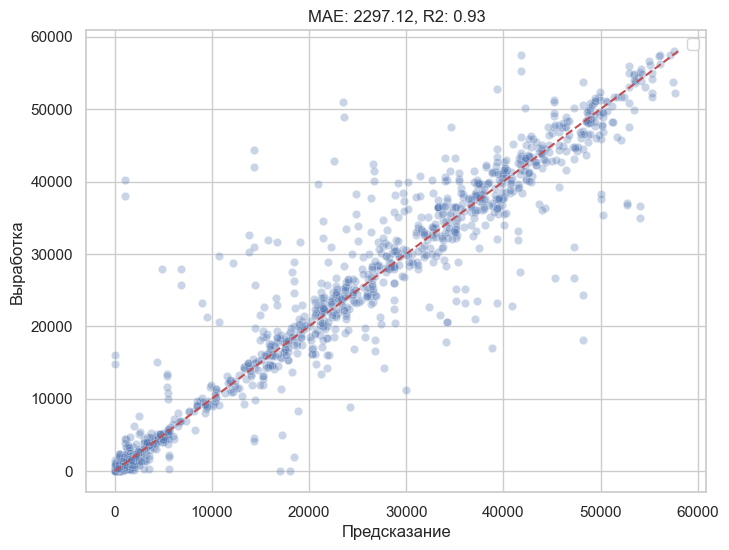

In [ ]:
decisionTree_RSCV = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees, 
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

decisionTree_RSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(decisionTree_RSCV.predict(x_test_p), y_test_p)


### HalvingGridSearchCV

#### На необработанных данных

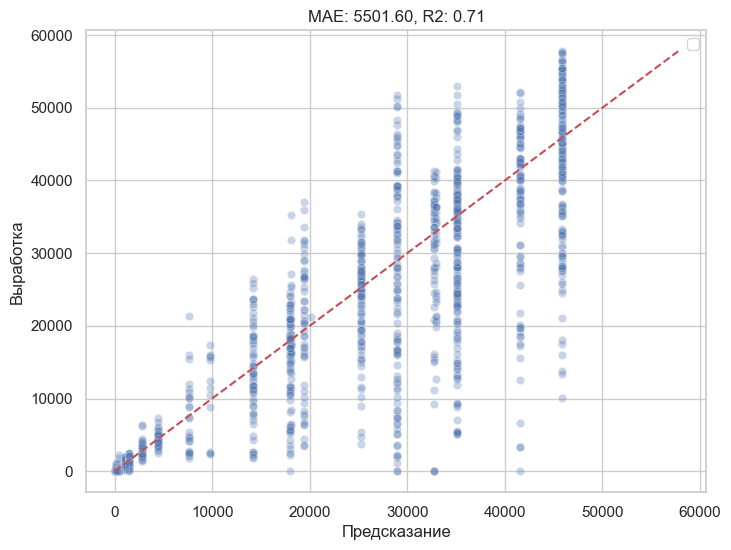

In [ ]:
decisionTree_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_for_trees,
    factor=2,
    resource='n_samples',
    cv=tscv,  
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

decisionTree_HGSCV.fit(x_train, y_train)

plot_predictions_vs_true(decisionTree_HGSCV.predict(x_test), y_test)

#### На обработанных данных

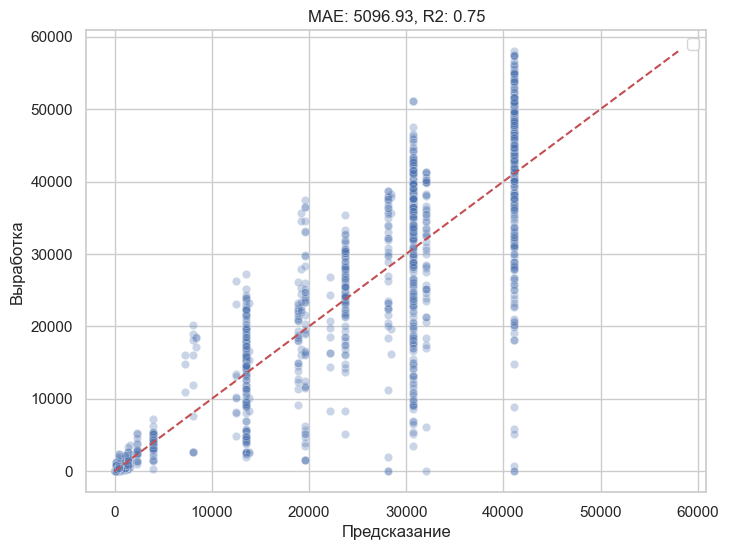

In [ ]:
decisionTree_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid_for_trees,
    factor=2,
    resource='n_samples',
    cv=tscv,  
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

decisionTree_HGSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(decisionTree_HGSCV.predict(x_test_p), y_test_p)

### HalvingRandomSearchCV

#### На необработанных данных

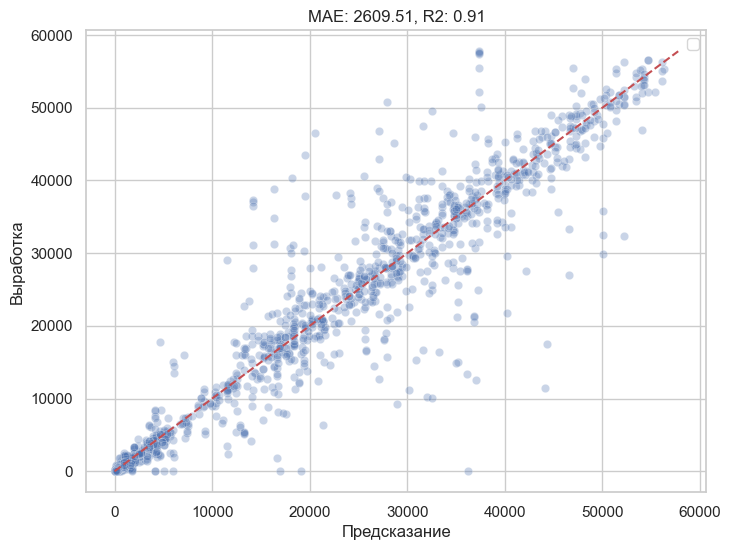

In [ ]:
decisionTree_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees,
    factor=3,
    resource='n_samples',
    n_candidates='exhaust',  
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

decisionTree_HRSCV.fit(x_train, y_train)

plot_predictions_vs_true(decisionTree_HRSCV.predict(x_test), y_test)


#### На обработанных данных

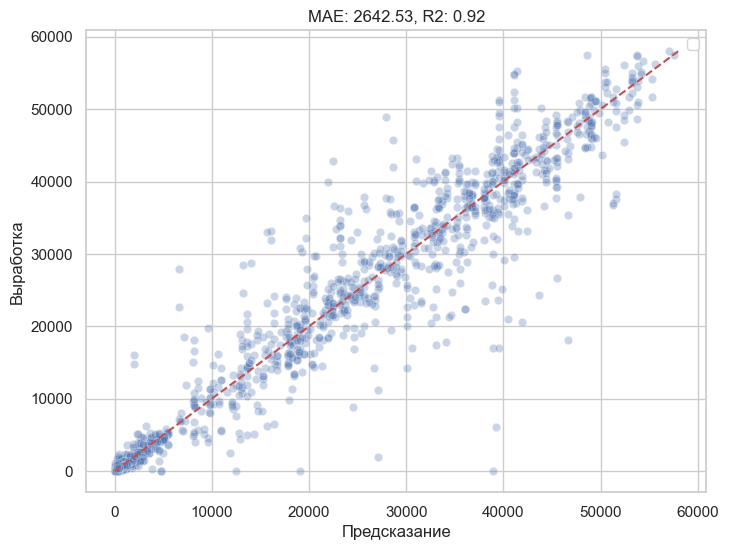

In [ ]:
decisionTree_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=param_grid_for_trees,
    factor=3,
    resource='n_samples',
    n_candidates='exhaust',  
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

decisionTree_HRSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(decisionTree_HRSCV.predict(x_test_p), y_test_p)


## Случайный лес

### GridSearchCV

#### На необработанных данных

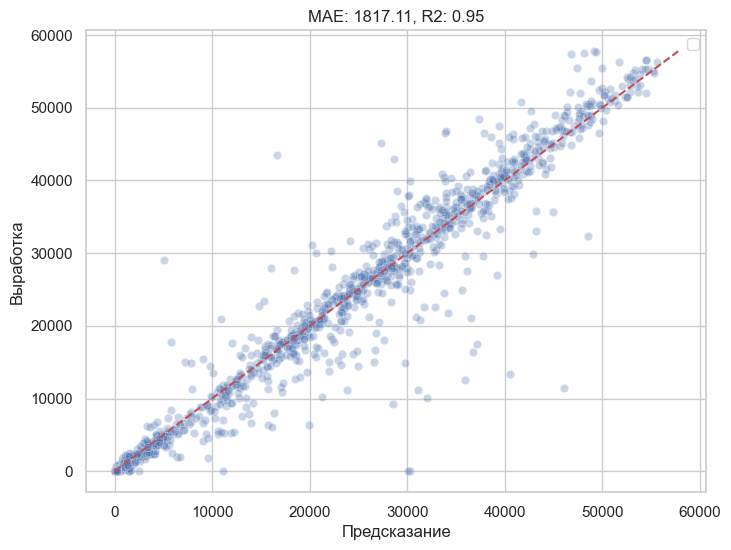

In [ ]:
random_forest_GSCV = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid_for_trees,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

random_forest_GSCV.fit(x_train, y_train)

plot_predictions_vs_true(random_forest_GSCV.predict(x_test), y_test)


#### На обработанных данных

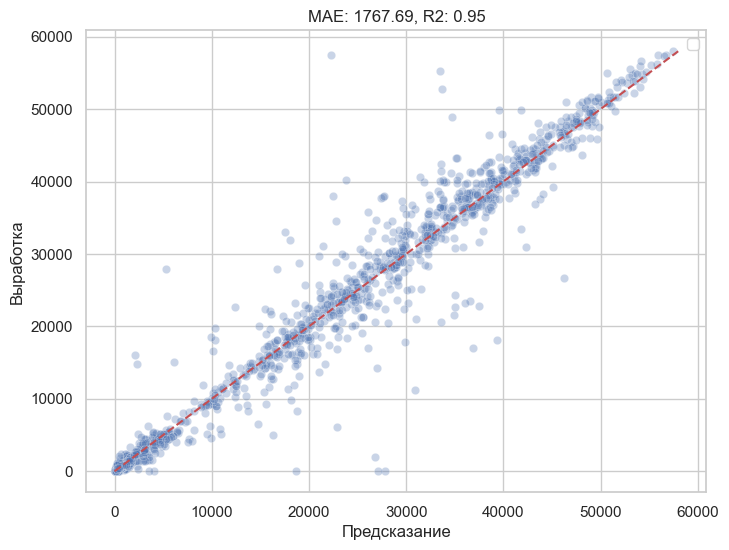

In [ ]:
random_forest_GSCV = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid_for_trees,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

random_forest_GSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(random_forest_GSCV.predict(x_test_p), y_test_p)


### RandomizedSearchCV

#### На необработанных данных

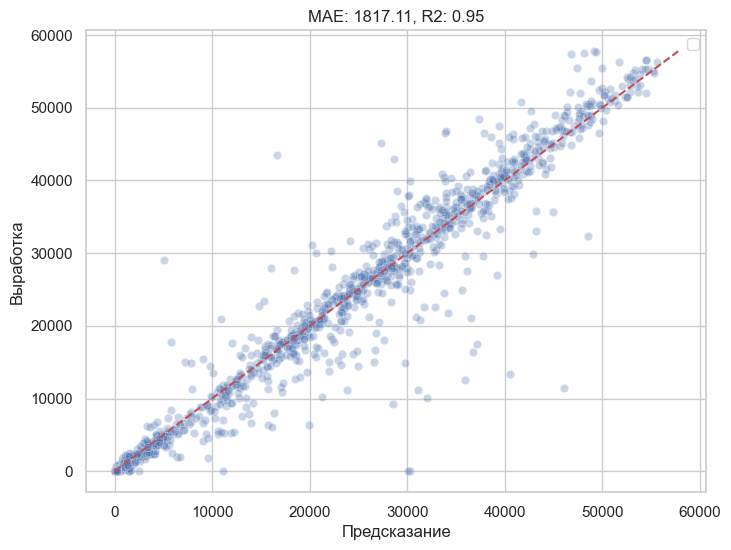

In [ ]:
random_forest_RSCV = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid_for_trees,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

random_forest_RSCV.fit(x_train, y_train)

plot_predictions_vs_true(random_forest_RSCV.predict(x_test), y_test)


#### На обработанных данных

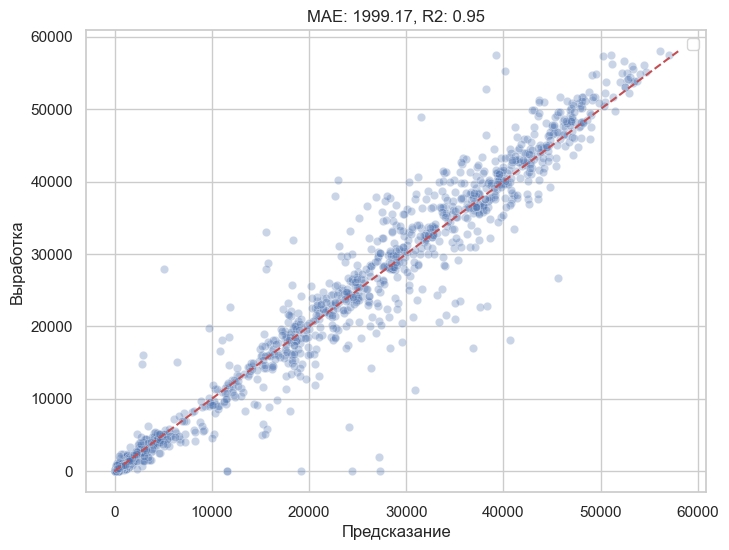

In [ ]:
random_forest_RSCV = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=param_grid_for_trees,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

random_forest_RSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(random_forest_RSCV.predict(x_test_p), y_test_p)


### HalvingGridSearchCV

#### На необработанных данных

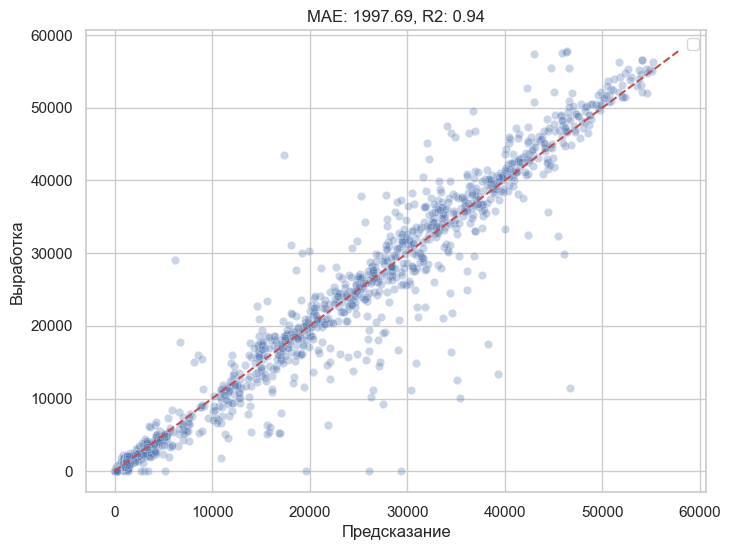

In [ ]:
random_forest_HSCV = enable_halving_search_cv.HalvingGridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_for_trees,
    factor=3,               
    resource='n_samples',  
    max_resources='auto',   
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

random_forest_HSCV.fit(x_train, y_train)

plot_predictions_vs_true(random_forest_HSCV.predict(x_test), y_test)


#### На обработанных данных

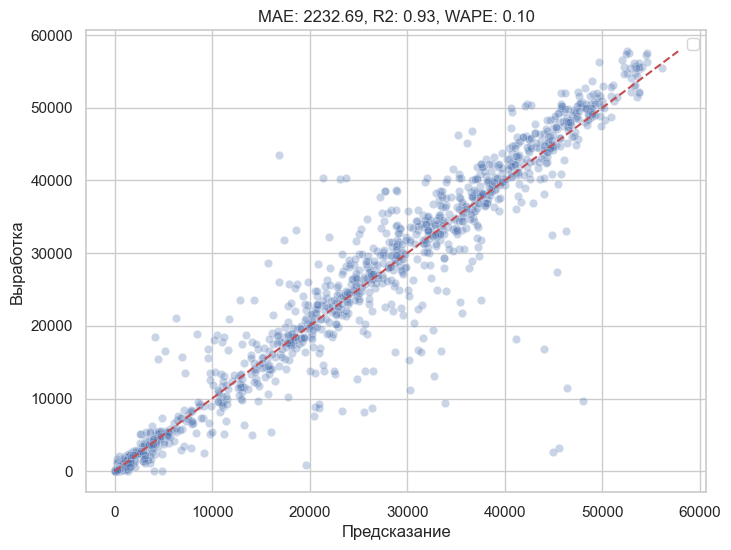

In [30]:
random_forest_HSCV = enable_halving_search_cv.HalvingGridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_for_trees,
    factor=3,               
    resource='n_samples',  
    max_resources='auto',   
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

random_forest_HSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(random_forest_HSCV.predict(x_test_p), y_test_p)


### HalvingRandomSearchCV


#### На необработанных данных

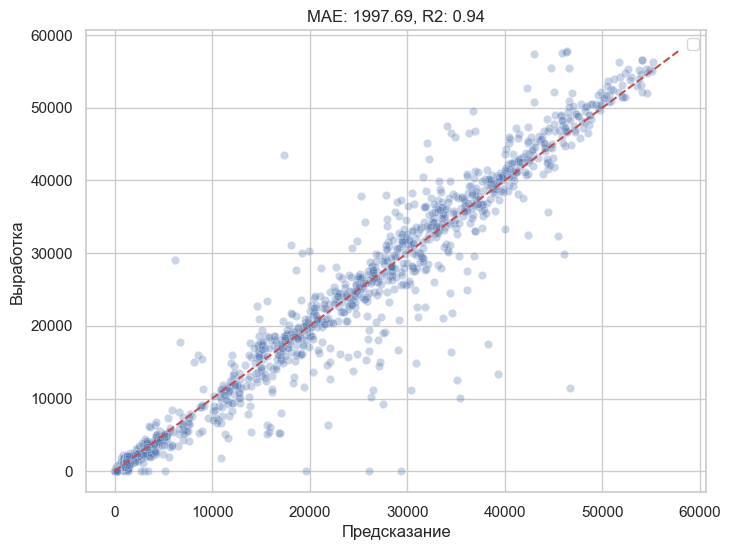

In [ ]:
random_forest_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_for_trees,
    factor=3,               
    resource='n_samples',   
    max_resources='auto',  
    cv=tscv, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

random_forest_HRSCV.fit(x_train, y_train)

plot_predictions_vs_true(random_forest_HRSCV.predict(x_test), y_test)


#### На обработанных данных

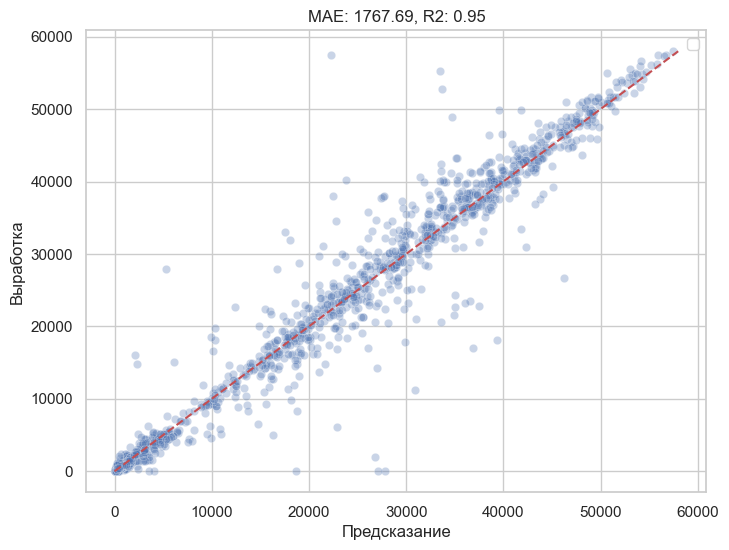

In [ ]:
random_forest_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_for_trees,
    factor=3,               
    resource='n_samples',   
    max_resources='auto',  
    cv=tscv, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

random_forest_HRSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(random_forest_HRSCV.predict(x_test_p), y_test_p)


## Градиентный бустинг


Инициализация сетки параметров для градиентного бустинга

In [ ]:
param_grid_for_gradient_boosting = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'l2_regularization': [0.0, 0.1, 1.0],
}

### GridSearchCV

#### На необработанных данных

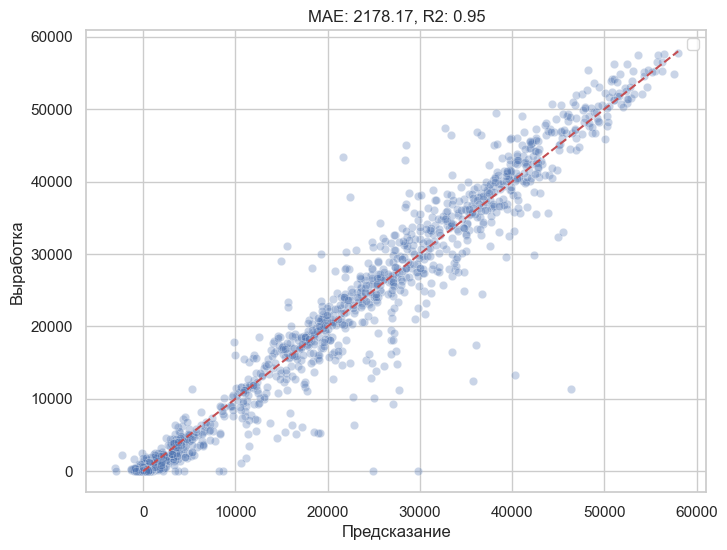

In [ ]:
histGradientBoosting_GSCV = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid=param_grid_for_gradient_boosting,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

histGradientBoosting_GSCV.fit(x_train, y_train)

plot_predictions_vs_true(histGradientBoosting_GSCV.predict(x_test), y_test)


#### На обработанных данных

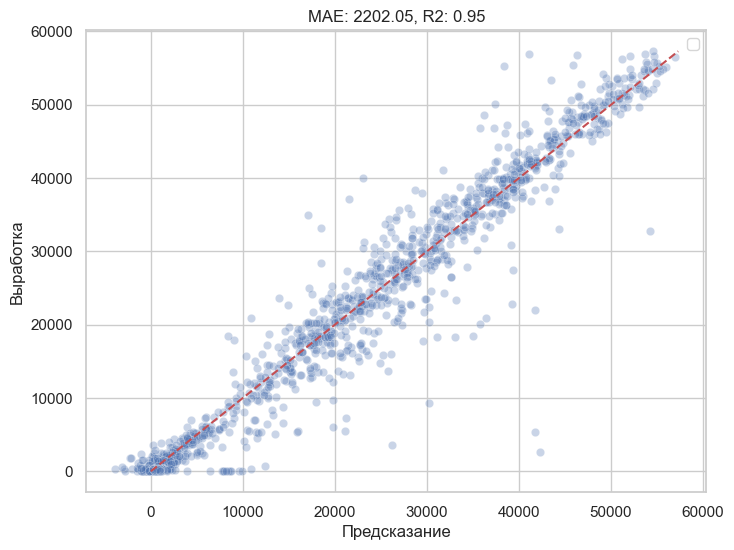

In [ ]:
histGradientBoosting_GSCV = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid=param_grid_for_gradient_boosting,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

histGradientBoosting_GSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(histGradientBoosting_GSCV.predict(x_test_p), y_test_p)


### RandomizedSearchCV

#### На необработанных данных

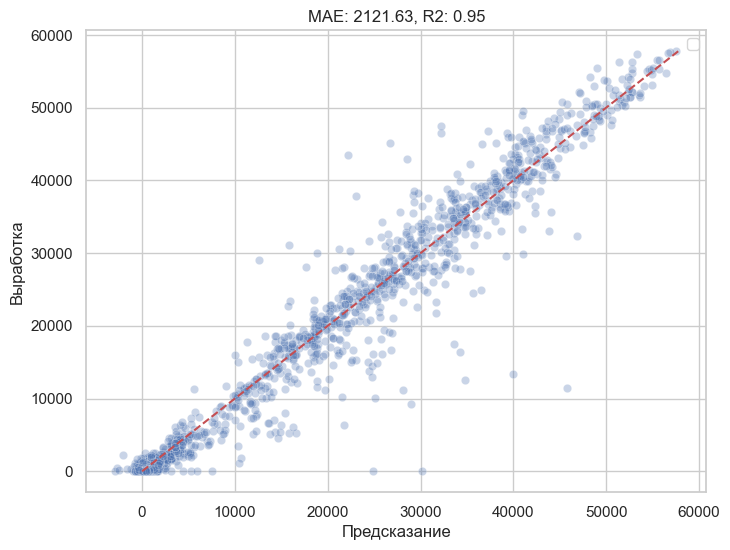

In [ ]:
histGradientBoosting_RSCV = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_for_gradient_boosting,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

histGradientBoosting_RSCV.fit(x_train, y_train)

plot_predictions_vs_true(histGradientBoosting_RSCV.predict(x_test), y_test)

#### На обработанных данных

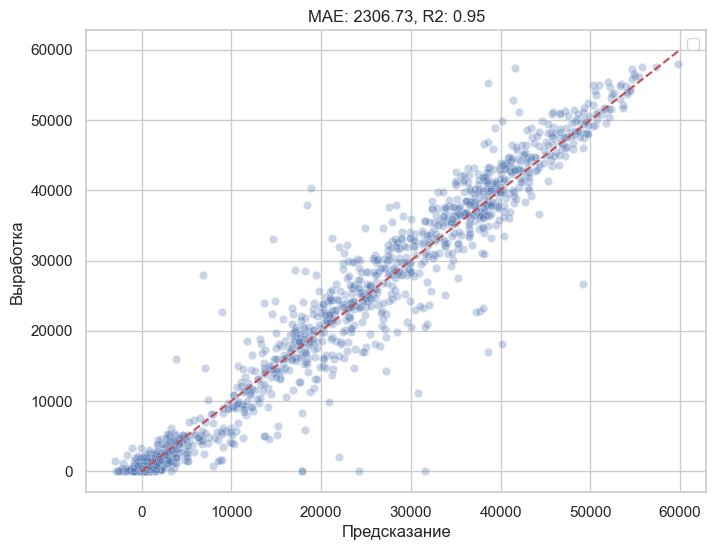

In [ ]:
histGradientBoosting_RSCV = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_for_gradient_boosting,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
histGradientBoosting_RSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(histGradientBoosting_RSCV.predict(x_test_p), y_test_p)

### HalvingGridSearchCV

#### На необработанных данных

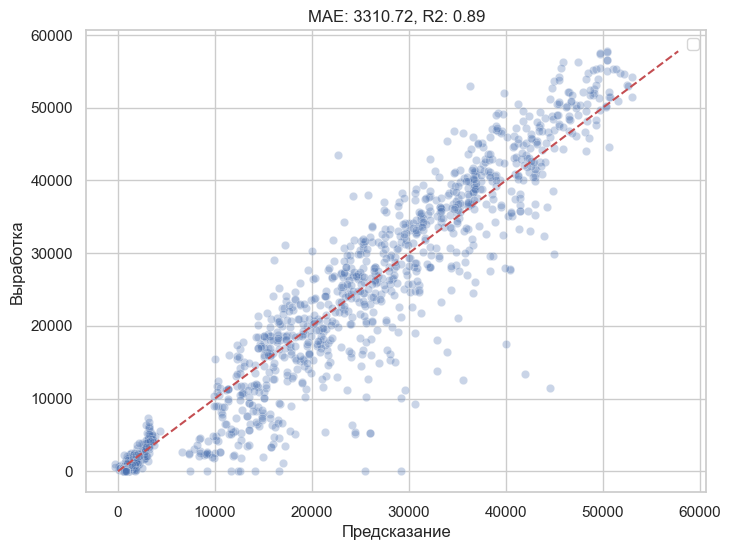

In [ ]:
histGradientBoosting_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid_for_gradient_boosting,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

histGradientBoosting_HGSCV.fit(x_train, y_train)

plot_predictions_vs_true(histGradientBoosting_HGSCV.predict(x_test), y_test)


#### На обработанных данных

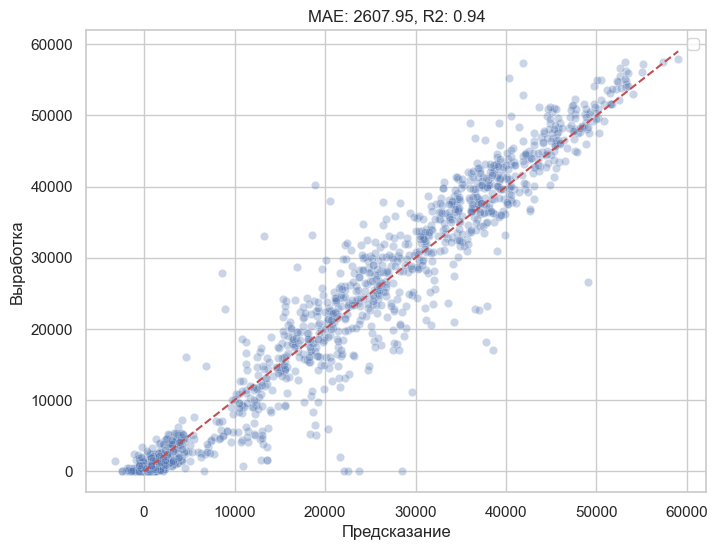

In [ ]:
histGradientBoosting_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_grid_for_gradient_boosting,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

histGradientBoosting_HGSCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(histGradientBoosting_HGSCV.predict(x_test_p), y_test_p)


### HalvingRandomSearchCV

#### На необработанных данных

In [ ]:
histGradientBoosing_HRCV = enable_halving_search_cv.HalvingRandomSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_for_trees,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

histGradientBoosing_HRCV.fit(x_train, y_train)

plot_predictions_vs_true(histGradientBoosing_HRCV.predict(x_test), y_test)


ValueError: Invalid parameter 'min_samples_split' for estimator HistGradientBoostingRegressor(random_state=42). Valid parameters are: ['categorical_features', 'early_stopping', 'interaction_cst', 'l2_regularization', 'learning_rate', 'loss', 'max_bins', 'max_depth', 'max_features', 'max_iter', 'max_leaf_nodes', 'min_samples_leaf', 'monotonic_cst', 'n_iter_no_change', 'quantile', 'random_state', 'scoring', 'tol', 'validation_fraction', 'verbose', 'warm_start'].

#### На обработанных данных

In [ ]:
histGradientBoosing_HRCV = enable_halving_search_cv.HalvingRandomSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_for_trees,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

histGradientBoosing_HRCV.fit(x_train_p, y_train_p)

plot_predictions_vs_true(histGradientBoosing_HRCV.predict(x_test_p), y_test_p)


## Нейронная сеть

Инициализация сетки параметров нейронной сети 

In [ ]:
param_grid_for_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

### GridSearchCV

#### На необработанных данных

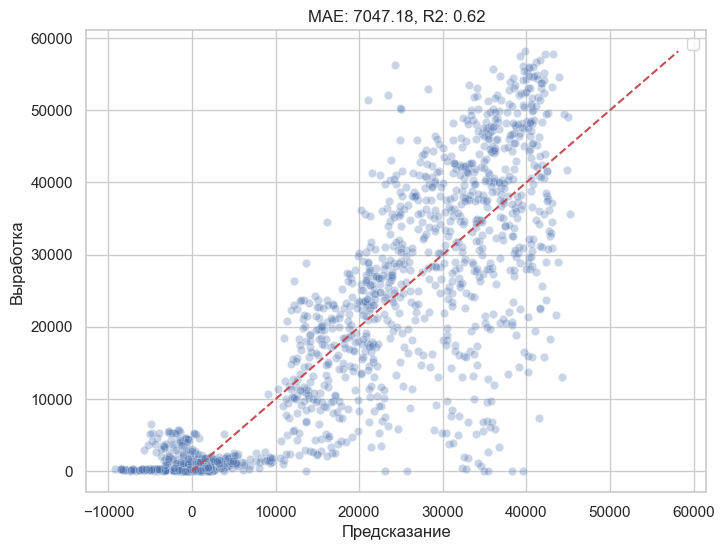

In [ ]:
MLP_GSCV = GridSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=500),
    param_grid=param_grid_for_mlp,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

MLP_GSCV.fit(x_train, y_train)
plot_predictions_vs_true(MLP_GSCV.predict(x_test), y_test)


#### На обработанных данных

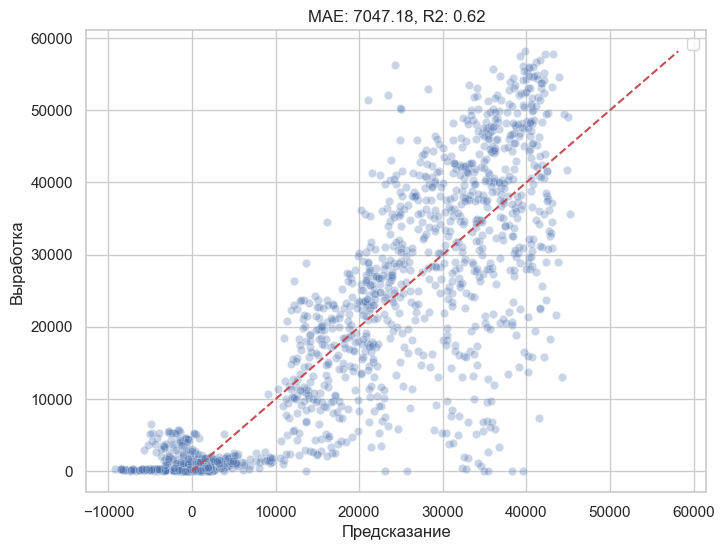

In [ ]:
MLP_GSCV = GridSearchCV(
    MLPRegressor(random_state=RANDOM_STATE, max_iter=500),
    param_grid=param_grid_for_mlp,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

MLP_GSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(MLP_GSCV.predict(x_test_p), y_test_p)


### RandomizedSearchCV

#### На необработанных данных

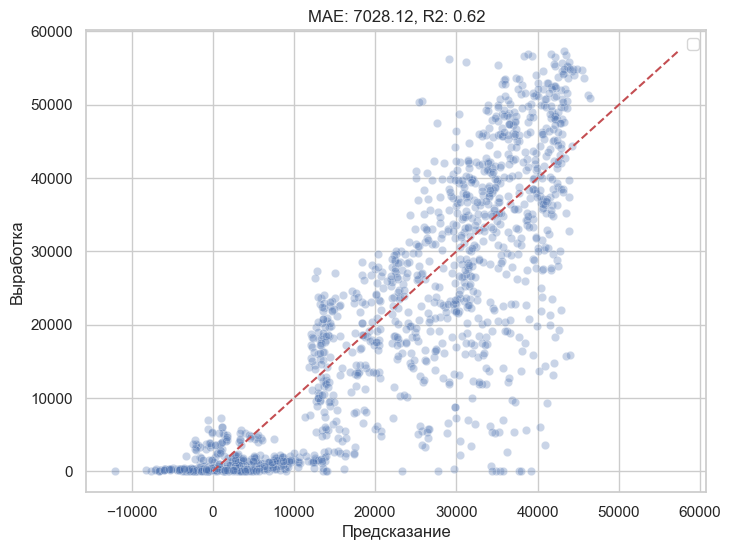

In [ ]:
MLP_RSCV = RandomizedSearchCV(
    MLPRegressor(random_state=42, max_iter=500),
    param_distributions=param_grid_for_mlp,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

MLP_RSCV.fit(x_train, y_train)
plot_predictions_vs_true(MLP_RSCV.predict(x_test), y_test)


#### На обработанных данных

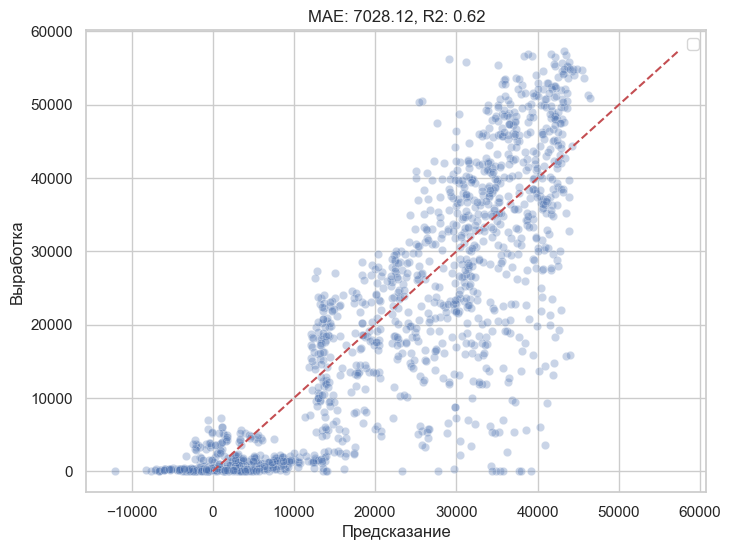

In [ ]:
MLP_RSCV = RandomizedSearchCV(
    MLPRegressor(random_state=42, max_iter=500),
    param_distributions=param_grid_for_mlp,
    n_iter=N_ITER_SEARCH,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

MLP_RSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(MLP_RSCV.predict(x_test_p), y_test_p)


### HalvingGridSearchCV

#### На необработанных данных

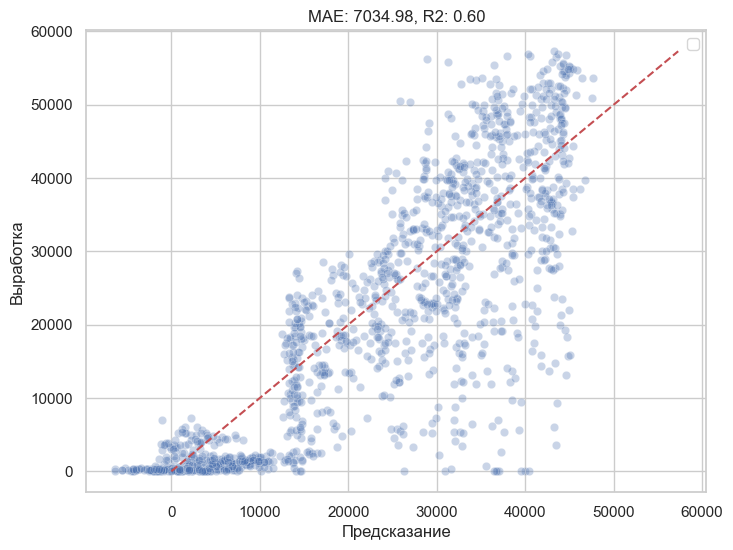

In [ ]:
MLP_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    MLPRegressor(random_state=42, max_iter=500),
    param_grid_for_mlp,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

MLP_HGSCV.fit(x_train, y_train)
plot_predictions_vs_true(MLP_HGSCV.predict(x_test), y_test)

#### На обработанных данных

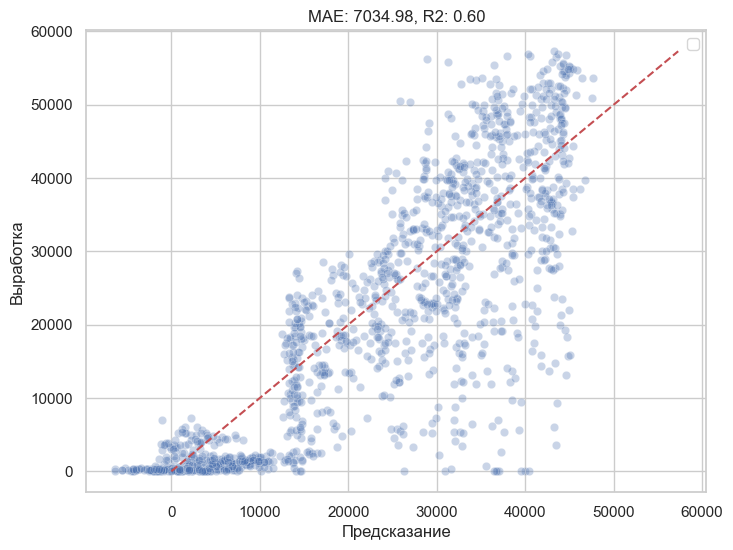

In [ ]:
MLP_HGSCV = enable_halving_search_cv.HalvingGridSearchCV(
    MLPRegressor(random_state=42, max_iter=500),
    param_grid_for_mlp,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

MLP_HGSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(MLP_HGSCV.predict(x_test_p), y_test_p)

### HalvingRandomSearchCV


#### На необработанных данных

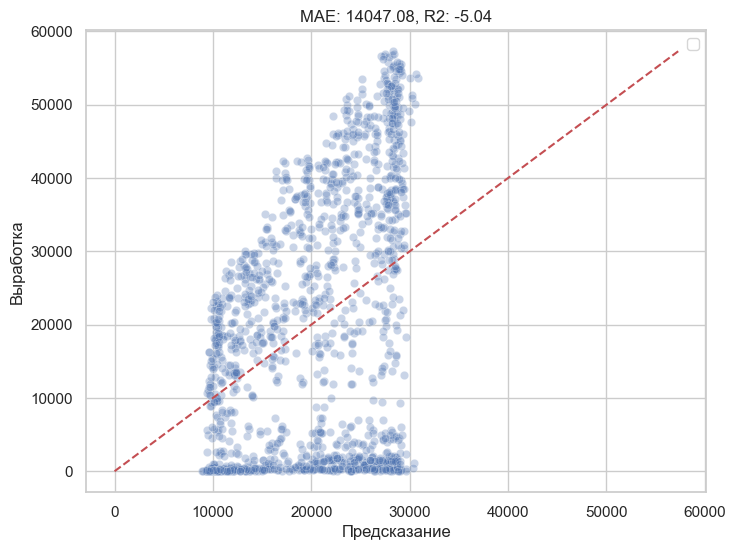

In [ ]:
MLP_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    MLPRegressor(random_state=42, max_iter=500),
    param_distributions=param_grid_for_mlp,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

MLP_HRSCV.fit(x_train, y_train)
plot_predictions_vs_true(MLP_HRSCV.predict(x_test), y_test)


#### На обработанных данных

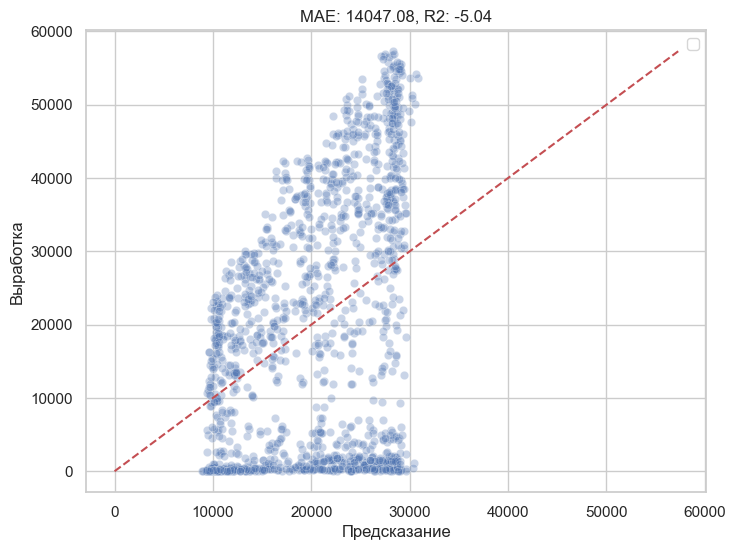

In [ ]:
MLP_HRSCV = enable_halving_search_cv.HalvingRandomSearchCV(
    MLPRegressor(random_state=42, max_iter=500),
    param_distributions=param_grid_for_mlp,
    factor=3,
    resource='n_samples',
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

MLP_HRSCV.fit(x_train_p, y_train_p)
plot_predictions_vs_true(MLP_HRSCV.predict(x_test_p), y_test_p)
